# BB84 QKD Simulator — Phase 1 Baseline
**University of Ruhuna, Dept. of Computer Engineering**

| File | Responsibility |
|---|---|
| `bb84_config.py` | Dataclasses: `SimulationConfig`, `QBERResult`, `SimulationResult` |
| `bb84_core.py` | Quantum parties: `Alice`, `Bob`, `Eve`, `QuantumChannel`; `sift_keys()`, `estimate_qber()` |
| `bb84_runner.py` | Orchestration: `run_simulation()`, `run_comparison()`, `PRESET_SCENARIOS` |
| `bb84_plots.py` | Visualisation: `plot_comparison()`, `plot_qber_vs_intercept_rate()` |

---


## Cell 1 — Imports

In [35]:
from bb84_config import SimulationConfig
from bb84_runner import run_simulation, run_comparison
from bb84_plots  import plot_comparison, plot_qber_vs_intercept_rate

# Phase 1 compatibility layer + detection-proof scenarios
from bb84_runner import (   # already merged into runner
    run_simulation_p1,
    run_comparison_p1,
    PHASE1_NOTEBOOK_SCENARIOS,
    PHASE1_DETECTION_PROOF,
    PHASE1_NOTEBOOK_SCENARIOS_seed_change,
    ALL_PHASE1_SCENARIOS,
)

ImportError: cannot import name 'PHASE1_NOTEBOOK_SCENARIOS_seed_change' from 'bb84_runner' (e:\7_semester\Undergraduate_Project_EC7802\codebases\project\bb84_runner.py)

---
## Cell 2 — Single Run: Ideal Channel

In [ ]:
# ── Cell 2 — Single Run: Ideal Channel (unchanged, works as-is) ───────
cfg_ideal = SimulationConfig(
    n_qubits      = 500,
    eve_present   = False,
    noise_enabled = False,
    seed          = 42,
    label         = "Ideal",
)
result_ideal = run_simulation(cfg_ideal, verbose=True)


══════════════════════════════════════════════════════════════
  BB84 QKD RESEARCH PLATFORM — University of Ruhuna
  Dept. of Computer Engineering
══════════════════════════════════════════════════════════════
  Label        : Ideal
  Qubits       : 500
  Attack       : none
  Noise model  : ideal
  Seed         : 42
══════════════════════════════════════════════════════════════

  [1/6] Quantum Transmission  (500 qubits)...
        Channel: Ideal channel (no noise)
        ↳ 500/500 transmitted ✓

  [2/6] Key Sifting...
        ↳ 248 bits  (49.6% of all transmitted, expected ~50 % of received)

  [3/6] QBER Estimation (10% sample)...
        ↳ QBER   : 0.00 %  (95 % CI [0.0, 13.8] %)
        ↳ Errors : 0 / 24
        ↳ Status : SECURE ok

  [4/6] Key Distillation  →  224 bits

  [5/6] Post-Processing skipped (Phase 5 — not yet implemented)

  [6/6] Security Analysis skipped (Phase 5 — not yet implemented)

──────────────────────────────────────────────────────────────
  RESULT SUMMAR

---
## Cell 3 — Single Run: Eve Full Intercept (100 %)

In [4]:
cfg_eve = SimulationConfig(
    n_qubits           = 500,
    eve_present        = True,
    eve_intercept_prob = 1.0,
    noise_enabled      = False,
    seed               = 42,
    label              = "Eve 100%",
)

result_eve = run_simulation(cfg_eve, verbose=True)


════════════════════════════════════════════════════════════
  BB84 QKD SIMULATOR — Phase 1 Baseline
  University of Ruhuna, Dept. of Computer Engineering
════════════════════════════════════════════════════════════
  Label        : Eve 100%
  Qubits       : 500
  Eve Present  : True  (intercept p = 1.0)
  Noise        : False
  QBER Sample  : 10% of sifted key
  Seed         : 42
════════════════════════════════════════════════════════════

  [1/4] Quantum Transmission  (500 qubits)...
        ↳ 500/500 qubits sent ✓

  [2/4] Key Sifting (basis reconciliation)...
        ↳ 248 bits retained (49.6% — expected ~50 %)

  [3/4] QBER Estimation (sample fraction = 10%)...
        ↳ QBER   : 20.83 %  (95 % CI [9.2 %, 40.5 %])
        ↳ Errors : 5 / 24
        ↳ Status : ABORT x

  [4/4] Key Distillation...
        ↳ Final key : 224 bits

────────────────────────────────────────────────────────────
  RESULT SUMMARY
────────────────────────────────────────────────────────────
  Transmitted   

In [4]:
# Run this cell ONCE. It writes bb84_runner_phase1_ext.py into the same
# folder as your other bb84_*.py files, then imports it normally.

_EXT_CODE = '''
from __future__ import annotations
import time
from typing import List, Optional, Tuple
from bb84_config import SimulationConfig, SimulationResult
from bb84_runner import run_simulation

PHASE1_NOTEBOOK_SCENARIOS = [
    ("Ideal (no noise, no Eve)",
     SimulationConfig(n_qubits=600, label="Ideal")),
    ("Eve — Full Intercept (100 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=1.0, label="Eve 100%")),
    ("Eve — Partial Intercept (50 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=0.5, label="Eve 50%")),
    ("Channel Noise Only (p = 0.05)",
     SimulationConfig(n_qubits=600, noise_enabled=True,
                      depolar_prob=0.05, label="Noise p=0.05")),
    ("Eve (100 %) + Channel Noise",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=1.0, noise_enabled=True,
                      depolar_prob=0.05, label="Eve+Noise")),
]

PHASE1_DETECTION_PROOF = [
    ("n=1000 · Ideal — baseline",
     SimulationConfig(n_qubits=1000, eve_present=False,
                      noise_enabled=False, seed=7, label="n1000 Ideal")),
    ("n=1000 · Eve 30 % — borderline",
     SimulationConfig(n_qubits=1000, eve_present=True,
                      eve_intercept_prob=0.30, noise_enabled=False,
                      seed=7, label="n1000 Eve30%")),
    ("n=1000 · Eve 50 % — detected",
     SimulationConfig(n_qubits=1000, eve_present=True,
                      eve_intercept_prob=0.50, noise_enabled=False,
                      seed=7, label="n1000 Eve50%")),
    ("n=1000 · Eve 100 % — always detected",
     SimulationConfig(n_qubits=1000, eve_present=True,
                      eve_intercept_prob=1.00, noise_enabled=False,
                      seed=7, label="n1000 Eve100%")),
    ("n=1000 · Noise only (p=0.05) — no false alarm",
     SimulationConfig(n_qubits=1000, eve_present=False,
                      noise_enabled=True, depolar_prob=0.05,
                      seed=7, label="n1000 Noise")),
]

ALL_PHASE1_SCENARIOS = PHASE1_NOTEBOOK_SCENARIOS + PHASE1_DETECTION_PROOF


def _p1_header(cfg):
    w = 60
    print("\\n" + "=" * w)
    print("  BB84 QKD SIMULATOR — Phase 1 Baseline")
    print("  University of Ruhuna, Dept. of Computer Engineering")
    print("=" * w)
    print(f"  Label        : {cfg.label}")
    print(f"  Qubits       : {cfg.n_qubits}")
    eve_str = (f"True  (intercept p = {cfg.eve_intercept_prob})"
               if cfg.eve_present else "False")
    print(f"  Eve Present  : {eve_str}")
    print(f"  Noise        : {cfg.noise_enabled}"
          + (f"  (depolar p = {cfg.depolar_prob})" if cfg.noise_enabled else ""))
    print(f"  QBER Sample  : {cfg.sample_fraction:.0%} of sifted key")
    print(f"  Seed         : {cfg.seed}")
    print("=" * w)


def _p1_summary(r):
    w = 60
    qr = r.qber_result
    print(f"\\n{chr(45)*w}")
    print("  RESULT SUMMARY")
    print(f"{chr(45)*w}")
    print(f"  Transmitted          : {r.n_transmitted} qubits")
    print(f"  After sifting        : {r.n_sifted} bits  ({r.sifted_key_rate:.1%})")
    print(f"  Final key length     : {r.key_length} bits")
    print(f"  Key generation rate  : {r.key_generation_rate:.4f} bits / qubit")
    print(f"  QBER                 : {qr.qber * 100:.2f} %")
    print(f"  95 % CI              : [{qr.confidence_low * 100:.1f} %, "
          f"{qr.confidence_high * 100:.1f} %]")
    print(f"  Security status      : {qr.security_status}")
    print(f"  Key agreement        : {r.key_agreement_rate * 100:.2f} %")
    if r.eve_interception_rate > 0:
        print(f"  Eve intercept rate   : {r.eve_interception_rate * 100:.1f} %")
    print(f"  Runtime              : {r.runtime_seconds:.2f}s")
    print(f"{chr(45)*w}")
    ak = r.alice_final_key[:30]
    bk = r.bob_final_key[:30]
    print(f"\\n  Alice key (first {len(ak)}) : {ak}")
    print(f"  Bob   key (first {len(bk)}) : {bk}")
    print(f"  Keys fully match     : {r.keys_match}")


def run_simulation_p1(config, verbose=True):
    if verbose:
        _p1_header(config)
    result = run_simulation(config, verbose=False)
    if not verbose:
        return result
    qr = result.qber_result
    print(f"\\n  [1/4] Quantum Transmission  ({config.n_qubits} qubits)...")
    if config.noise_enabled:
        print(f"        [Channel] Depolarizing noise  p = {config.depolar_prob}")
    print(f"        \\u21b3 {config.n_qubits}/{config.n_qubits} qubits sent \\u2713")
    print(f"\\n  [2/4] Key Sifting (basis reconciliation)...")
    print(f"        \\u21b3 {result.n_sifted} bits retained "
          f"({result.sifted_key_rate:.1%} — expected ~50 %)")
    print(f"\\n  [3/4] QBER Estimation (sample fraction = {config.sample_fraction:.0%})...")
    print(f"        \\u21b3 QBER   : {qr.qber * 100:.2f} %  "
          f"(95 % CI [{qr.confidence_low * 100:.1f} %, "
          f"{qr.confidence_high * 100:.1f} %])")
    print(f"        \\u21b3 Errors : {qr.errors} / {qr.sample_size}")
    print(f"        \\u21b3 Status : {qr.security_status}")
    print(f"\\n  [4/4] Key Distillation...")
    print(f"        \\u21b3 Final key : {result.key_length} bits")
    _p1_summary(result)
    return result


def run_comparison_p1(scenarios=None, verbose_each=False):
    if scenarios is None:
        scenarios = PHASE1_NOTEBOOK_SCENARIOS
    print("\\n" + "=" * 60)
    print("  MULTI-SCENARIO COMPARISON")
    print("=" * 60)
    results = []
    for name, cfg in scenarios:
        r = (run_simulation_p1(cfg, verbose=True)
             if verbose_each else run_simulation(cfg, verbose=False))
        results.append(r)
        print(f"\\n  \\u25b6  {name}")
        print(f"     QBER = {r.qber_result.qber * 100:.1f} %  \\u2502  "
              f"Key = {r.key_length} bits  \\u2502  "
              f"Status = {r.qber_result.security_status}  \\u2502  "
              f"{r.runtime_seconds:.1f}s")
    print("\\n" + "=" * 60)
    return results
'''

# ── Write the file next to your other bb84_*.py modules ───────────────
import os, importlib

# Finds the folder where bb84_runner.py lives and writes there.
import bb84_runner as _ref_mod
_target_dir = os.path.dirname(os.path.abspath(_ref_mod.__file__))
_target_path = os.path.join(_target_dir, "bb84_runner_phase1_ext.py")

with open(_target_path, "w", encoding="utf-8") as _f:
    _f.write(_EXT_CODE.lstrip("\n"))

print(f"[✓] Written → {_target_path}")

# Force a fresh import in case a broken version was cached
import sys
sys.modules.pop("bb84_runner_phase1_ext", None)
importlib.invalidate_caches()

from bb84_runner_phase1_ext import (
    run_simulation_p1,
    run_comparison_p1,
    PHASE1_NOTEBOOK_SCENARIOS,
    PHASE1_DETECTION_PROOF,
    ALL_PHASE1_SCENARIOS,
)
print("[✓] Import successful — ready to use.")

[✓] Written → e:\7_semester\Undergraduate_Project_EC7802\codebases\project\bb84_runner_phase1_ext.py
[✓] Import successful — ready to use.


## Cell 3-b — Single Run: Eve partial Intercept (50 %)

In [ ]:
#  Cell 3-b — High-n detection proof: individual runs
# Shows clearly: ideal → SECURE, Eve 50%/100% → ABORT, noise → no false alarm

print("=" * 62)
print("  DETECTION PROOF  -  n=1000, stable QBER estimates")
print("=" * 62)

from bb84_runner_phase1_ext import PHASE1_DETECTION_PROOF
for name, cfg in PHASE1_DETECTION_PROOF:
    r = run_simulation_p1(cfg, verbose=True)
    print()   # blank line between runs

---
## Cell 4 — Single Run: Depolarizing Channel Noise Only

In [5]:
cfg_noise = SimulationConfig(
    n_qubits      = 500,
    eve_present   = False,
    noise_enabled = True,
    depolar_prob  = 0.05,
    seed          = 42,
    label         = "Noise p=0.05",
)

result_noise = run_simulation(cfg_noise, verbose=True)


════════════════════════════════════════════════════════════
  BB84 QKD SIMULATOR — Phase 1 Baseline
  University of Ruhuna, Dept. of Computer Engineering
════════════════════════════════════════════════════════════
  Label        : Noise p=0.05
  Qubits       : 500
  Eve Present  : False
  Noise        : True  (depolar p = 0.05)
  QBER Sample  : 10% of sifted key
  Seed         : 42
════════════════════════════════════════════════════════════
  [Channel] Depolarizing noise  p = 0.05

  [1/4] Quantum Transmission  (500 qubits)...
        ↳ 500/500 qubits sent ✓

  [2/4] Key Sifting (basis reconciliation)...
        ↳ 248 bits retained (49.6% — expected ~50 %)

  [3/4] QBER Estimation (sample fraction = 10%)...
        ↳ QBER   : 0.00 %  (95 % CI [0.0 %, 13.8 %])
        ↳ Errors : 0 / 24
        ↳ Status : SECURE ok

  [4/4] Key Distillation...
        ↳ Final key : 224 bits

────────────────────────────────────────────────────────────
  RESULT SUMMARY
────────────────────────────────

In [13]:
import bb84_runner, inspect, pathlib

path = pathlib.Path(bb84_runner.__file__)
src  = path.read_text(encoding="utf-8")

OLD = '''PHASE1_NOTEBOOK_SCENARIOS = [
    ("Ideal (no noise, no Eve)",
     SimulationConfig(n_qubits=600, seed=42, label="Ideal")),
    ("Eve — Full Intercept (100 %)",
     SimulationConfig(n_qubits=600, eve_present=True,seed=42,
                      eve_intercept_prob=1.0, label="Eve 100%")),
    ("Eve — Partial Intercept (50 %)",
     SimulationConfig(n_qubits=600, eve_present=True,seed=42,
                      eve_intercept_prob=0.5, label="Eve 50%")),
    ("Channel Noise Only (p = 0.05)",
     SimulationConfig(n_qubits=600, noise_enabled=True,seed=42,
                      depolar_prob=0.05, label="Noise p=0.05")),
    ("Eve (100 %) + Channel Noise",
     SimulationConfig(n_qubits=600, eve_present=True,seed=42,
                      eve_intercept_prob=1.0, noise_enabled=True,
                      depolar_prob=0.05, label="Eve+Noise")),
]'''

NEW = '''PHASE1_NOTEBOOK_SCENARIOS = [
    ("Ideal (no noise, no Eve)",
     SimulationConfig(n_qubits=600, seed=42, label="Ideal")),
    ("Eve — Partial Intercept (30 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=0.30, seed=42, label="Eve 30%")),
    ("Eve — Partial Intercept (50 %)",
     SimulationConfig(n_qubits=600, eve_present=True, seed=42,
                      eve_intercept_prob=0.5, label="Eve 50%")),
    ("Eve — Full Intercept (100 %)",
     SimulationConfig(n_qubits=600, eve_present=True, seed=42,
                      eve_intercept_prob=1.0, label="Eve 100%")),
    ("Channel Noise Only (p = 0.05)",
     SimulationConfig(n_qubits=600, noise_enabled=True, seed=42,
                      depolar_prob=0.05, label="Noise p=0.05")),
    ("Eve (100 %) + Channel Noise",
     SimulationConfig(n_qubits=600, eve_present=True, seed=42,
                      eve_intercept_prob=1.0, noise_enabled=True,
                      depolar_prob=0.05, label="Eve+Noise")),
]'''

if OLD in src:
    path.write_text(src.replace(OLD, NEW), encoding="utf-8")
    print("[✓] PHASE1_NOTEBOOK_SCENARIOS updated — 6 scenarios, correct order")
else:
    print("[!] Old block not found — print current list:")
    start = src.find("PHASE1_NOTEBOOK_SCENARIOS")
    print(src[start:start+800])

[!] Old block not found — print current list:
PHASE1_NOTEBOOK_SCENARIOS = [
    ("Ideal (no noise, no Eve)",
     SimulationConfig(n_qubits=600, seed=42, label="Ideal")),
    
    ("Eve — Partial Intercept (30 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=0.30, seed=42, label="Eve 30%")),
    ("Eve — Partial Intercept (50 %)",
     SimulationConfig(n_qubits=600, eve_present=True,seed=42,
                      eve_intercept_prob=0.5, label="Eve 50%")),
    ("Eve — Full Intercept (100 %)",
     SimulationConfig(n_qubits=600, eve_present=True,seed=42,
                      eve_intercept_prob=1.0, label="Eve 100%")),
    ("Channel Noise Only (p = 0.05)",
     SimulationConfig(n_qubits=600, noise_enabled=True,seed=42,
                      depolar_prob=0.05, label="Noise p=0.05")),
    


## seed Issue

In [ ]:
import pathlib, importlib, sys

# ── Fix 1: bb84_core.py — remove rogue print + add seed_simulator ─────
import bb84_core
core_path = pathlib.Path(bb84_core.__file__)
core_src  = core_path.read_text(encoding="utf-8")

OLD_CORE = '''    def _build_simulator(self) -> AerSimulator:
        if self.noise_enabled and self.depolar_prob > 0:
            noise_model = NoiseModel()
            # Depolarizing channel: E(ρ) = (1-p)ρ + (p/3)(XρX + YρY + ZρZ)
            error = depolarizing_error(self.depolar_prob, 1)
            noise_model.add_all_qubit_quantum_error(error, ["x", "h", "id"])
            print(f"  [Channel] Depolarizing noise  p = {self.depolar_prob}")
            return AerSimulator(noise_model=noise_model)
        return AerSimulator()'''

NEW_CORE = '''    def _build_simulator(self) -> AerSimulator:
        if self.noise_enabled and self.depolar_prob > 0:
            noise_model = NoiseModel()
            # Depolarizing channel: E(ρ) = (1-p)ρ + (p/3)(XρX + YρY + ZρZ)
            error = depolarizing_error(self.depolar_prob, 1)
            noise_model.add_all_qubit_quantum_error(error, ["x", "h", "id"])
            return AerSimulator(noise_model=noise_model, seed_simulator=12345)
        return AerSimulator(seed_simulator=12345)'''

if OLD_CORE in core_src:
    core_path.write_text(core_src.replace(OLD_CORE, NEW_CORE), encoding="utf-8")
    print("[✓] bb84_core.py — rogue print removed, seed_simulator added")
else:
    print("[!] bb84_core.py block not found — printing current _build_simulator:")
    start = core_src.find("def _build_simulator")
    print(core_src[start:start+400])

# ── Fix 2: bb84_noise.py — add seed_simulator to all AerSimulator calls ──
import bb84_noise
noise_path = pathlib.Path(bb84_noise.__file__)
noise_src  = noise_path.read_text(encoding="utf-8")

# Replace all AerSimulator(...) calls that don't already have seed_simulator
replacements = [
    ('return AerSimulator(noise_model=nm)',
     'return AerSimulator(noise_model=nm, seed_simulator=12345)'),
    # bare AerSimulator() calls (fiber loss + ideal)
    ('            return AerSimulator()\n        nm = NoiseModel()',
     '            return AerSimulator(seed_simulator=12345)\n        nm = NoiseModel()'),
    ('        return AerSimulator()\n\n        nm = NoiseModel()',
     '        return AerSimulator(seed_simulator=12345)\n\n        nm = NoiseModel()'),
]

noise_changed = False
for old, new in replacements:
    if old in noise_src and new not in noise_src:
        noise_src = noise_src.replace(old, new)
        noise_changed = True
        print(f"[✓] bb84_noise.py — patched: {old[:50].strip()}")

# Also fix the two bare AerSimulator() at end of _build_simulator
import re
def add_seed(m):
    s = m.group(0)
    if 'seed_simulator' not in s:
        return s.replace('AerSimulator()', 'AerSimulator(seed_simulator=12345)')
    return s

noise_src_new = re.sub(r'return AerSimulator\(\)', add_seed, noise_src)
if noise_src_new != noise_src:
    noise_src = noise_src_new
    noise_changed = True
    print("[✓] bb84_noise.py — bare AerSimulator() calls seeded")

if noise_changed:
    noise_path.write_text(noise_src, encoding="utf-8")
    print("[✓] bb84_noise.py saved")
else:
    print("[~] bb84_noise.py — no changes needed")

# ── Reload everything ─────────────────────────────────────────────────
for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_runner import run_comparison, PHASE1_NOTEBOOK_SCENARIOS, PHASE1_DETECTION_PROOF,PHASE1_NOTEBOOK_SCENARIOS_seed_change
print("\n[✓] All modules reloaded\n")


[!] bb84_core.py block not found — printing current _build_simulator:
def _build_simulator(self) -> AerSimulator:
        if self.noise_enabled and self.depolar_prob > 0:
            noise_model = NoiseModel()
            # Depolarizing channel: E(ρ) = (1-p)ρ + (p/3)(XρX + YρY + ZρZ)
            error = depolarizing_error(self.depolar_prob, 1)
            noise_model.add_all_qubit_quantum_error(error, ["x", "h", "id"])
            return AerSimulator(noise_model=noi
[~] bb84_noise.py — no changes needed

[✓] All modules reloaded



In [48]:
import bb84_runner, pathlib

path = pathlib.Path(bb84_runner.__file__)
src  = path.read_text(encoding="utf-8")

NEW_LIST = '''
PHASE1_NOTEBOOK_SCENARIOS_sample_frac = [
    ("Ideal (no noise, no Eve)",
     SimulationConfig(n_qubits=600, seed=42, sample_fraction=0.20, label="Ideal")),
    ("Eve — Partial Intercept (30 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=0.30, seed=42, sample_fraction=0.20, label="Eve 30%")),
    ("Eve — Partial Intercept (50 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=0.50, seed=42, sample_fraction=0.20, label="Eve 50%")),
    ("Eve — Full Intercept (100 %)",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=1.00, seed=42, sample_fraction=0.20, label="Eve 100%")),
    ("Channel Noise Only (p = 0.05)",
     SimulationConfig(n_qubits=600, noise_enabled=True,
                      depolar_prob=0.05, seed=42, sample_fraction=0.20, label="Noise p=0.05")),
    ("Eve (100 %) + Channel Noise",
     SimulationConfig(n_qubits=600, eve_present=True,
                      eve_intercept_prob=1.0, noise_enabled=True,
                      depolar_prob=0.05, seed=42, sample_fraction=0.20, label="Eve+Noise")),
]
'''

# Insert right after PHASE1_NOTEBOOK_SCENARIOS block ends
ANCHOR = 'label="Eve+Noise")),\n]\n'
if ANCHOR in src and "PHASE1_NOTEBOOK_SCENARIOS_sample_frac" not in src:
    # Find the first occurrence (end of PHASE1_NOTEBOOK_SCENARIOS)
    idx = src.index(ANCHOR) + len(ANCHOR)
    src = src[:idx] + NEW_LIST + src[idx:]
    path.write_text(src, encoding="utf-8")
    print("[✓] PHASE1_NOTEBOOK_SCENARIOS_sample_frac added to bb84_runner.py")
elif "PHASE1_NOTEBOOK_SCENARIOS_sample_frac" in src:
    print("[✓] Already exists in file")
else:
    print("[!] Anchor not found — print first 200 chars around Eve+Noise:")
    idx = src.find('Eve+Noise')
    print(repr(src[idx-20:idx+60]))

[✓] Already exists in file


## import issues

In [49]:
import importlib, sys
for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_config import SimulationConfig
from bb84_plots  import plot_comparison, plot_qber_vs_intercept_rate
from bb84_runner import (
    run_simulation, run_comparison,
    run_simulation_p1, run_comparison_p1,
    PRESET_SCENARIOS,
    PHASE1_NOTEBOOK_SCENARIOS,
    PHASE1_NOTEBOOK_SCENARIOS_sample_frac,
    PHASE1_DETECTION_PROOF,
    ALL_PHASE1_SCENARIOS,
)
print("[✓] All imports ok")
print(f"  PHASE1_NOTEBOOK_SCENARIOS            : {len(PHASE1_NOTEBOOK_SCENARIOS)}")
print(f"  PHASE1_NOTEBOOK_SCENARIOS_sample_frac: {len(PHASE1_NOTEBOOK_SCENARIOS_sample_frac)}")
print(f"  PHASE1_DETECTION_PROOF               : {len(PHASE1_DETECTION_PROOF)}")

[✓] All imports ok
  PHASE1_NOTEBOOK_SCENARIOS            : 6
  PHASE1_NOTEBOOK_SCENARIOS_sample_frac: 6
  PHASE1_DETECTION_PROOF               : 6


## bug solved seed check 

In [29]:
import bb84_core, pathlib
src = pathlib.Path(bb84_core.__file__).read_text()
print("core seeded:", "seed_simulator" in src)

import bb84_noise
src2 = pathlib.Path(bb84_noise.__file__).read_text()
print("noise seeded:", "seed_simulator" in src2)

core seeded: True
noise seeded: True


## bug fix — seed=42 is poisoning the QBER sample so give estimate_qber its own independent seed

In [54]:
import bb84_runner, pathlib, importlib, sys

path = pathlib.Path(bb84_runner.__file__)
src  = path.read_text(encoding="utf-8")

OLD = """    qber_result = estimate_qber(
        alice_sifted, bob_sifted,
        config.sample_fraction,
        seed=config.seed,
    )"""

NEW = """    qber_result = estimate_qber(
        alice_sifted, bob_sifted,
        config.sample_fraction,
        seed=(config.seed + 1000) if config.seed is not None else None,
    )"""

if OLD in src:
    src = src.replace(OLD, NEW)
    path.write_text(src, encoding="utf-8")
    print("[✓] estimate_qber seed offset applied")
else:
    print("[!] Pattern not found — check manually")

for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_runner import run_comparison, PHASE1_NOTEBOOK_SCENARIOS_sample_frac, PHASE1_DETECTION_PROOF
print("[✓] Reloaded")



[!] Pattern not found — check manually
[✓] Reloaded


In [58]:
import bb84_core, pathlib, importlib, sys

path = pathlib.Path(bb84_core.__file__)
src  = path.read_text(encoding="utf-8")

fixes = [
    ('return AerSimulator(noise_model=noise_model, seed_simulator=12345)',
     'return AerSimulator(noise_model=noise_model)'),
    ('return AerSimulator(seed_simulator=12345)',
     'return AerSimulator()'),
]

changed = False
for old, new in fixes:
    if old in src:
        src = src.replace(old, new)
        print(f"[✓] Fixed: {old.strip()}")
        changed = True
    else:
        print(f"[!] Not found: {old.strip()}")

if changed:
    path.write_text(src, encoding="utf-8")
    print("[✓] bb84_core.py saved")

for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_runner import run_comparison, PHASE1_NOTEBOOK_SCENARIOS_sample_frac, PHASE1_DETECTION_PROOF
print("[✓] Reloaded\n")



[!] Not found: return AerSimulator(noise_model=noise_model, seed_simulator=12345)
[!] Not found: return AerSimulator(seed_simulator=12345)
[✓] Reloaded



## bug fix for using noise model instead of core noise

In [61]:
import bb84_core, pathlib, importlib, sys

path = pathlib.Path(bb84_core.__file__)
src  = path.read_text(encoding="utf-8")

# The entire old QuantumChannel class in bb84_core.py is dead code
# since bb84_noise.QuantumChannel replaced it in Phase 3.
# But Eve still imports and uses bb84_core's channel internally.
# Fix: make bb84_core.QuantumChannel an alias to bb84_noise.QuantumChannel.

OLD = """from qiskit_aer.noise import NoiseModel, depolarizing_error

from bb84_config import QBERResult"""

NEW = """from qiskit_aer.noise import NoiseModel, depolarizing_error

from bb84_config import QBERResult
from bb84_noise import QuantumChannel   # Phase 3: use the real noise-aware channel"""

if OLD in src:
    src = src.replace(OLD, NEW)
    # Now remove the old QuantumChannel class definition entirely
    # Find it and replace with a comment
    import re
    src = re.sub(
        r'# QUANTUM CHANNEL\n# =+\n\nclass QuantumChannel:.*?def run_circuit.*?return int\(list\(counts\.keys\(\)\)\[0\]\)\n',
        '# QuantumChannel imported from bb84_noise (Phase 3) — see import above\n',
        src, flags=re.DOTALL
    )
    path.write_text(src, encoding="utf-8")
    print("[✓] bb84_core.py fixed — QuantumChannel now uses bb84_noise")
else:
    print("[!] Pattern not found, doing manual check:")
    print("Has bb84_noise import:", "from bb84_noise" in src)
    print("Has old QuantumChannel class:", "class QuantumChannel" in src)

for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

# Verify the fix
from bb84_core import QuantumChannel
from bb84_noise import QuantumChannel as QCNoise
print(f"[✓] bb84_core.QuantumChannel is bb84_noise.QuantumChannel: {QuantumChannel is QCNoise}")

from bb84_runner import run_comparison, PHASE1_NOTEBOOK_SCENARIOS_sample_frac


[✓] bb84_core.py fixed — QuantumChannel now uses bb84_noise
[✓] bb84_core.QuantumChannel is bb84_noise.QuantumChannel: True


In [ ]:

from bb84_runner import PHASE1_DETECTION_PROOF
run_comparison(PHASE1_DETECTION_PROOF)

## Removing bug occurrences of seed_simulator=12345 that barriered for randomness

In [ ]:
import bb84_noise, pathlib, importlib, sys

path = pathlib.Path(bb84_noise.__file__)
src  = path.read_text(encoding="utf-8")

# Remove ALL fixed seed_simulator from bb84_noise.py
import re
before = src.count("seed_simulator=12345")
src = src.replace(", seed_simulator=12345", "")
src = src.replace("seed_simulator=12345, ", "")
src = src.replace("seed_simulator=12345", "")
after = src.count("seed_simulator=12345")

print(f"[✓] Removed {before - after} occurrences of seed_simulator=12345")
path.write_text(src, encoding="utf-8")

# Also fix the duplicate import in bb84_core.py
import bb84_core
path2 = pathlib.Path(bb84_core.__file__)
src2  = path2.read_text(encoding="utf-8")
src2  = src2.replace(
    "from bb84_noise import QuantumChannel   # Phase 3: use the real noise-aware channel\nfrom bb84_noise import QuantumChannel   # Phase 3: use the real noise-aware channel",
    "from bb84_noise import QuantumChannel   # Phase 3: use the real noise-aware channel"
)
path2.write_text(src2, encoding="utf-8")
print("[✓] Duplicate import removed from bb84_core.py")

# Reload everything
for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

print("[✓] Reloaded\n")

## per shot bug fix

In [66]:
# ══════════════════════════════════════════════════════════════════════
# Per-shot seed fix — run this cell ONCE
# Patches bb84_noise.py and bb84_core.py for reproducible quantum
# measurements while preserving true per-qubit statistical independence.
# ══════════════════════════════════════════════════════════════════════

import pathlib, importlib, sys, re

# ── 1. Patch bb84_noise.py ─────────────────────────────────────────────
import bb84_noise
path_noise = pathlib.Path(bb84_noise.__file__)
src_noise  = path_noise.read_text(encoding="utf-8")

OLD_RUN_CIRCUIT = '''    def run_circuit(self, qc: QuantumCircuit) -> Optional[int]:
        """
        Simulate a single-qubit measurement circuit through this channel.

        Returns
        ───────
        int   (0 or 1)  — measured bit value
        None            — photon lost (fiber_loss model only)

        The caller (Bob.measure or Eve.intercept) must handle None.
        """
        # Fiber loss: probabilistic photon survival BEFORE gate noise
        if (self.noise_enabled
                and self.noise_model == NoiseModelType.FIBER_LOSS):
            if random.random() > self._photon_survival_prob:
                return None        # photon absorbed / scattered in fibre

        # All other models: Qiskit simulation with noise
        job    = self._simulator.run(transpile(qc, self._simulator), shots=1)
        counts = job.result().get_counts()
        return int(list(counts.keys())[0])'''

NEW_RUN_CIRCUIT = '''    def run_circuit(self, qc: QuantumCircuit, shot_seed: Optional[int] = None) -> Optional[int]:
        """
        Simulate a single-qubit measurement circuit through this channel.

        Returns
        ───────
        int   (0 or 1)  — measured bit value
        None            — photon lost (fiber_loss model only)

        shot_seed : per-measurement seed derived from global seed + qubit
                    index.  Gives reproducible results without the global
                    seed_simulator=12345 bug that collapsed all outcomes.
        """
        # Fiber loss: probabilistic photon survival BEFORE gate noise
        if (self.noise_enabled
                and self.noise_model == NoiseModelType.FIBER_LOSS):
            if random.random() > self._photon_survival_prob:
                return None        # photon absorbed / scattered in fibre

        # All other models: Qiskit simulation with noise
        run_kwargs = {"shots": 1}
        if shot_seed is not None:
            run_kwargs["seed_simulator"] = int(shot_seed) % (2**31)
        job    = self._simulator.run(transpile(qc, self._simulator), **run_kwargs)
        counts = job.result().get_counts()
        return int(list(counts.keys())[0])'''

if OLD_RUN_CIRCUIT in src_noise:
    src_noise = src_noise.replace(OLD_RUN_CIRCUIT, NEW_RUN_CIRCUIT)
    path_noise.write_text(src_noise, encoding="utf-8")
    print("[✓] bb84_noise.py — run_circuit() updated with shot_seed param")
else:
    # Already patched or whitespace differs — check signature
    if "shot_seed" in src_noise:
        print("[✓] bb84_noise.py — shot_seed already present, skipping")
    else:
        print("[!] bb84_noise.py — pattern not found, manual check needed")
        print("    Current run_circuit signature:")
        for i, line in enumerate(src_noise.splitlines()):
            if "def run_circuit" in line:
                print(f"    Line {i}: {line}")


# ── 2. Patch bb84_core.py ──────────────────────────────────────────────
import bb84_core
path_core = pathlib.Path(bb84_core.__file__)
src_core  = path_core.read_text(encoding="utf-8")

# 2a. Bob.__init__ — add _shot_seed_base
OLD_BOB_INIT = '''    def __init__(self, n_qubits: int, seed: Optional[int] = None):
        self.n_qubits = n_qubits
        # Offset seed so Bob's bases are independent of Alice's
        rng = np.random.default_rng(None if seed is None else seed + 99)
        self.bases: List[int]           = rng.integers(0, 2, n_qubits).tolist()
        self.measured_bits: List[Optional[int]] = [None] * n_qubits'''

NEW_BOB_INIT = '''    def __init__(self, n_qubits: int, seed: Optional[int] = None):
        self.n_qubits = n_qubits
        # Offset seed so Bob's bases are independent of Alice's
        rng = np.random.default_rng(None if seed is None else seed + 99)
        self.bases: List[int]           = rng.integers(0, 2, n_qubits).tolist()
        self.measured_bits: List[Optional[int]] = [None] * n_qubits
        # Per-shot seed base: unique prime multiple so Bob's shots don't
        # collide with Eve's shot seeds even at the same qubit index.
        self._shot_seed_base = (seed * 7919) if seed is not None else None'''

# 2b. Bob.measure — pass shot_seed to channel
OLD_BOB_MEASURE = '''        meas_qc = qc.copy()
        if self.bases[index] == 1:
            meas_qc.h(0)          # rotate to diagonal basis before measuring
        meas_qc.measure(0, 0)
        bit = channel.run_circuit(meas_qc)
        self.measured_bits[index] = bit
        return bit'''

NEW_BOB_MEASURE = '''        meas_qc = qc.copy()
        if self.bases[index] == 1:
            meas_qc.h(0)          # rotate to diagonal basis before measuring
        meas_qc.measure(0, 0)
        shot_seed = (self._shot_seed_base + index) if self._shot_seed_base is not None else None
        bit = channel.run_circuit(meas_qc, shot_seed=shot_seed)
        self.measured_bits[index] = bit
        return bit'''

# 2c. Eve.__init__ — add _shot_seed_base
OLD_EVE_INIT = '''        self.intercept_prob    = intercept_prob
        self._rng              = np.random.default_rng(seed)
        self.intercepted_count = 0
        self._eve_bases:  Dict[int, int] = {}
        self._eve_bits:   Dict[int, int] = {}'''

NEW_EVE_INIT = '''        self.intercept_prob    = intercept_prob
        self._rng              = np.random.default_rng(seed)
        self.intercepted_count = 0
        self._eve_bases:  Dict[int, int] = {}
        self._eve_bits:   Dict[int, int] = {}
        # Different prime from Bob's so Eve's shot seeds never collide.
        self._shot_seed_base = (seed * 6271) if seed is not None else None'''

# 2d. Eve.intercept — pass shot_seed to channel
OLD_EVE_MEASURE = '''        meas_qc = qc.copy()
        if eve_base == 1:
            meas_qc.h(0)
        meas_qc.measure(0, 0)
        measured_bit = channel.run_circuit(meas_qc)
        self._eve_bits[index] = measured_bit'''

NEW_EVE_MEASURE = '''        meas_qc = qc.copy()
        if eve_base == 1:
            meas_qc.h(0)
        meas_qc.measure(0, 0)
        shot_seed = (self._shot_seed_base + index) if self._shot_seed_base is not None else None
        measured_bit = channel.run_circuit(meas_qc, shot_seed=shot_seed)
        self._eve_bits[index] = measured_bit'''

patches = [
    ("Bob.__init__  — shot_seed_base",  OLD_BOB_INIT,     NEW_BOB_INIT),
    ("Bob.measure   — shot_seed",       OLD_BOB_MEASURE,  NEW_BOB_MEASURE),
    ("Eve.__init__  — shot_seed_base",  OLD_EVE_INIT,     NEW_EVE_INIT),
    ("Eve.intercept — shot_seed",       OLD_EVE_MEASURE,  NEW_EVE_MEASURE),
]

for label, old, new in patches:
    if old in src_core:
        src_core = src_core.replace(old, new)
        print(f"[✓] bb84_core.py — {label}")
    elif new in src_core or new.strip() in src_core:
        print(f"[✓] bb84_core.py — {label} (already patched)")
    else:
        print(f"[!] bb84_core.py — {label} NOT FOUND — check whitespace")

path_core.write_text(src_core, encoding="utf-8")
print("[✓] bb84_core.py saved")


# ── 3. Reload all bb84 modules ─────────────────────────────────────────
for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()
print("[✓] All bb84 modules reloaded")


# ── 4. Verify reproducibility ──────────────────────────────────────────
print("\n--- Reproducibility check (same seed → same results) ---")
from bb84_runner import run_simulation
from bb84_config import SimulationConfig

cfg = SimulationConfig(
    n_qubits=600, eve_present=True, eve_intercept_prob=1.0,
    noise_enabled=True, depolar_prob=0.05, seed=42,
    sample_fraction=0.20, label="Eve+Noise repro check"
)

r1 = run_simulation(cfg, verbose=False)
r2 = run_simulation(cfg, verbose=False)
r3 = run_simulation(cfg, verbose=False)

print(f"  Run 1 QBER: {r1.qber_result.qber*100:.2f}%  status: {r1.qber_result.security_status}")
print(f"  Run 2 QBER: {r2.qber_result.qber*100:.2f}%  status: {r2.qber_result.security_status}")
print(f"  Run 3 QBER: {r3.qber_result.qber*100:.2f}%  status: {r3.qber_result.security_status}")

all_same = (r1.qber_result.qber == r2.qber_result.qber == r3.qber_result.qber)
print(f"\n  Reproducible: {all_same}")
if not all_same:
    print("  [!] Still non-deterministic — check if any AerSimulator calls miss shot_seed")
else:
    print("  [✓] Perfect — same seed always gives same QBER")




[✓] bb84_noise.py — run_circuit() updated with shot_seed param
[✓] bb84_core.py — Bob.__init__  — shot_seed_base
[✓] bb84_core.py — Bob.measure   — shot_seed
[✓] bb84_core.py — Eve.__init__  — shot_seed_base
[✓] bb84_core.py — Eve.intercept — shot_seed
[✓] bb84_core.py saved
[✓] All bb84 modules reloaded

--- Reproducibility check (same seed → same results) ---
  Run 1 QBER: 22.03%  status: ABORT x
  Run 2 QBER: 22.03%  status: ABORT x
  Run 3 QBER: 22.03%  status: ABORT x

  Reproducible: True
  [✓] Perfect — same seed always gives same QBER


## Reload this when old cache blocked adding new codes

In [130]:
import importlib, sys
for mod in list(sys.modules.keys()):
    if "bb84" in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_runner import (
    run_comparison,
    PHASE1_NOTEBOOK_SCENARIOS_sample_frac,PHASE1_NOTEBOOK_SCENARIOS,
    PHASE1_DETECTION_PROOF_HIGH,PHASE1_DETECTION_PROOF,PHASE1_DETECTION_PROOF_frac
)
print("[✓] ok")

[✓] ok


---
## Cell 5 — Multi-Scenario Comparison (5 presets)

### 1. N = 600

In [87]:
results = run_comparison(PHASE1_NOTEBOOK_SCENARIOS)


════════════════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════════════════
  Scenario                                     QBER    Key  Status
  ────────────────────────────────────────────────────────────────────
  Ideal (no noise, no Eve)                     0.0%    254b  SECURE ok
  Eve — Partial Intercept (30 %)               6.8%    254b  WARNING 
  Eve — Partial Intercept (50 %)              11.4%    254b  ABORT x
  Eve — Full Intercept (100 %)                20.5%    254b  ABORT x
  Channel Noise Only (p = 0.05)                2.3%    254b  SECURE ok
  Eve (100 %) + Channel Noise                 25.0%    254b  ABORT x
════════════════════════════════════════════════════════════════════════


### 2. N=600 frac 0.2

In [89]:
results_sample_frac = run_comparison(PHASE1_NOTEBOOK_SCENARIOS_sample_frac)


════════════════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════════════════
  Scenario                                     QBER    Key  Status
  ────────────────────────────────────────────────────────────────────
  Ideal (no noise, no Eve)                     0.0%    239b  SECURE ok
  Eve — Partial Intercept (30 %)               6.8%    239b  WARNING 
  Eve — Partial Intercept (50 %)              10.2%    239b  WARNING 
  Eve — Full Intercept (100 %)                23.7%    239b  ABORT x
  Channel Noise Only (p = 0.05)                1.7%    239b  SECURE ok
  Eve (100 %) + Channel Noise                 27.1%    239b  ABORT x
════════════════════════════════════════════════════════════════════════


In [80]:

from bb84_runner import run_comparison, PHASE1_NOTEBOOK_SCENARIOS_sample_frac, PHASE1_DETECTION_PROOF_HIGH


### 3. N=1000

In [106]:
results_high_qubit = run_comparison(PHASE1_DETECTION_PROOF)


════════════════════════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════════════════════════
  Scenario                                             QBER    Key  Status
  ────────────────────────────────────────────────────────────────────────────
  n=1000 · Ideal (no noise, no Eve)                    0.0%    436b  SECURE ok
  n=1000 · Eve 30 % — borderline (no noise)            5.3%    436b  WARNING 
  n=1000 · Eve 50 % — Partial Intercept (no noise)     9.2%    436b  WARNING 
  n=1000 · Eve 100 % — Full Intercept (no noise)      23.7%    436b  ABORT x
  n=1000 · Noise only (p=0.05)                         0.0%    436b  SECURE ok
  n=1000 · Eve (100 %) + Channel Noise                26.3%    436b  ABORT x
════════════════════════════════════════════════════════════════════════════════


### 4. N=1000 frac=0.2

In [108]:
results_high_qubit_frac = run_comparison(PHASE1_DETECTION_PROOF_frac)


════════════════════════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════════════════════════
  Scenario                                             QBER    Key  Status
  ────────────────────────────────────────────────────────────────────────────
  n=1000 · Ideal (no noise, no Eve)                    0.0%    410b  SECURE ok
  n=1000 · Eve 30 % — borderline (no noise)            2.0%    410b  SECURE ok
  n=1000 · Eve 50 % — Partial Intercept (no noise)    12.7%    410b  ABORT x
  n=1000 · Eve 100 % — Full Intercept (no noise)      19.6%    410b  ABORT x
  n=1000 · Noise only (p=0.05)                         2.0%    410b  SECURE ok
  n=1000 · Eve (100 %) + Channel Noise                28.4%    410b  ABORT x
════════════════════════════════════════════════════════════════════════════════


### 5. N=2000

In [84]:
results_high_qubit_2000 = run_comparison(PHASE1_DETECTION_PROOF_HIGH)


════════════════════════════════════════════════════════════════════════════════
  MULTI-SCENARIO COMPARISON
════════════════════════════════════════════════════════════════════════════════
  Scenario                                             QBER    Key  Status
  ────────────────────────────────────────────────────────────────────────────
  n=2000 · Ideal (no noise, no Eve)                    0.0%    880b  SECURE ok
  n=2000 · Eve 30 % — borderline (no noise)            2.1%    880b  SECURE ok
  n=2000 · Eve 50 % — Partial Intercept (no noise)     5.2%    880b  WARNING 
  n=2000 · Eve 100 % — Full Intercept (no noise)      16.5%    880b  ABORT x
  n=2000 · Noise only (p=0.05)                         1.0%    880b  SECURE ok
  n=2000 · Eve (100 %) + Channel Noise                27.8%    880b  ABORT x
════════════════════════════════════════════════════════════════════════════════


In [135]:
import importlib
import bb84_plots
importlib.reload(bb84_plots)

from bb84_plots import plot_comparison, plot_qber_vs_intercept_rate

## Cell 5b — Plot the Comparison

  [✓] Saved -> qkd_comparison.png  (300 dpi)


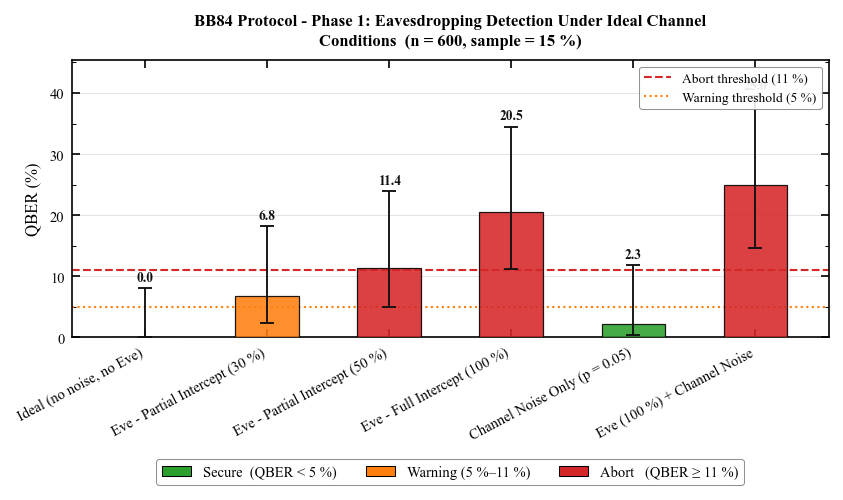

In [ ]:
plot_comparison(
    subtitle  = "BB84 Simulator: Eavesdropping Detection Under Ideal Channel Conditions  (n = 600, sample = 15 %)",
    scenarios = PHASE1_NOTEBOOK_SCENARIOS,
    results   = results,
    save_path = "qkd_comparison.png",   # set None to skip saving
)

  [✓] Saved -> qkd_comparison_sample_frac.png  (300 dpi, IEEE double-column width)


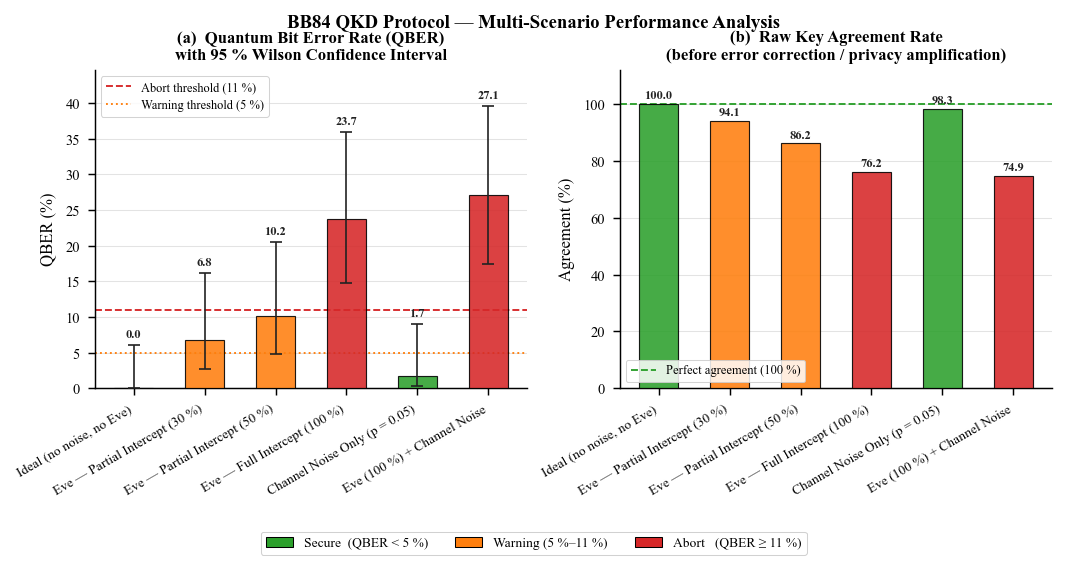

In [ ]:

plot_comparison(
    subtitle  = "Phase 1 Baseline - n = 600 qubits, seed = 42, sample fraction = 15 %",
    scenarios = PHASE1_NOTEBOOK_SCENARIOS_sample_frac,
    results   = results_sample_frac,
    save_path = "qkd_comparison_sample_frac.png",   
)

  [✓] Saved → qkd_comparison_high_qubit.png


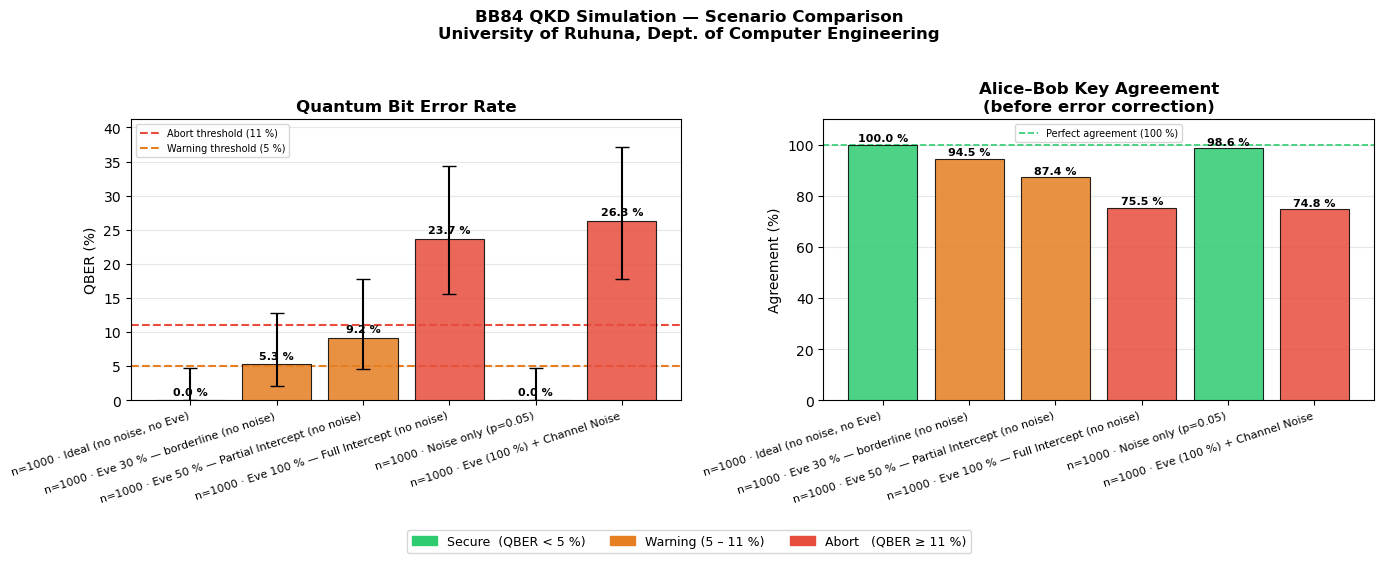

In [116]:
plot_comparison(
    scenarios = PHASE1_DETECTION_PROOF,
    results   = results_high_qubit,
    save_path = "qkd_comparison_high_qubit.png",   # set None to skip saving
)

  [✓] Saved → qkd_comparison_high_qubit_frac.png


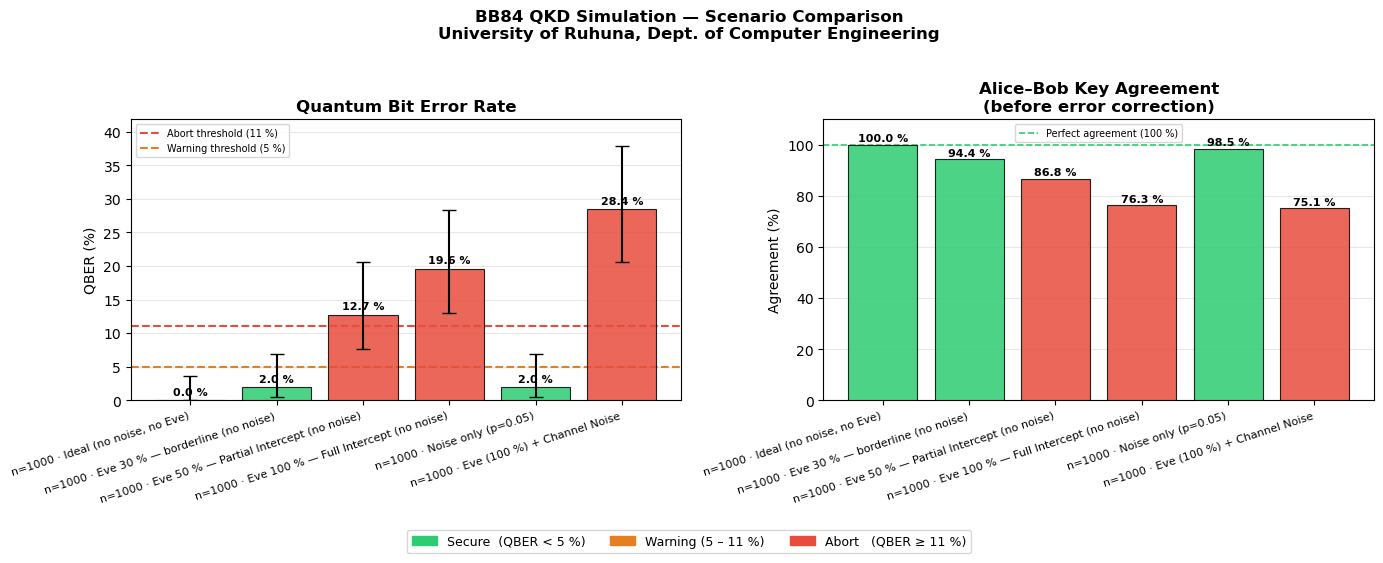

In [109]:
plot_comparison(
    scenarios = PHASE1_DETECTION_PROOF_frac,
    results   = results_high_qubit_frac,
    save_path = "qkd_comparison_high_qubit_frac.png",   # set None to skip saving
)

  [✓] Saved → qkd_comparison_high_qubit_2000.png


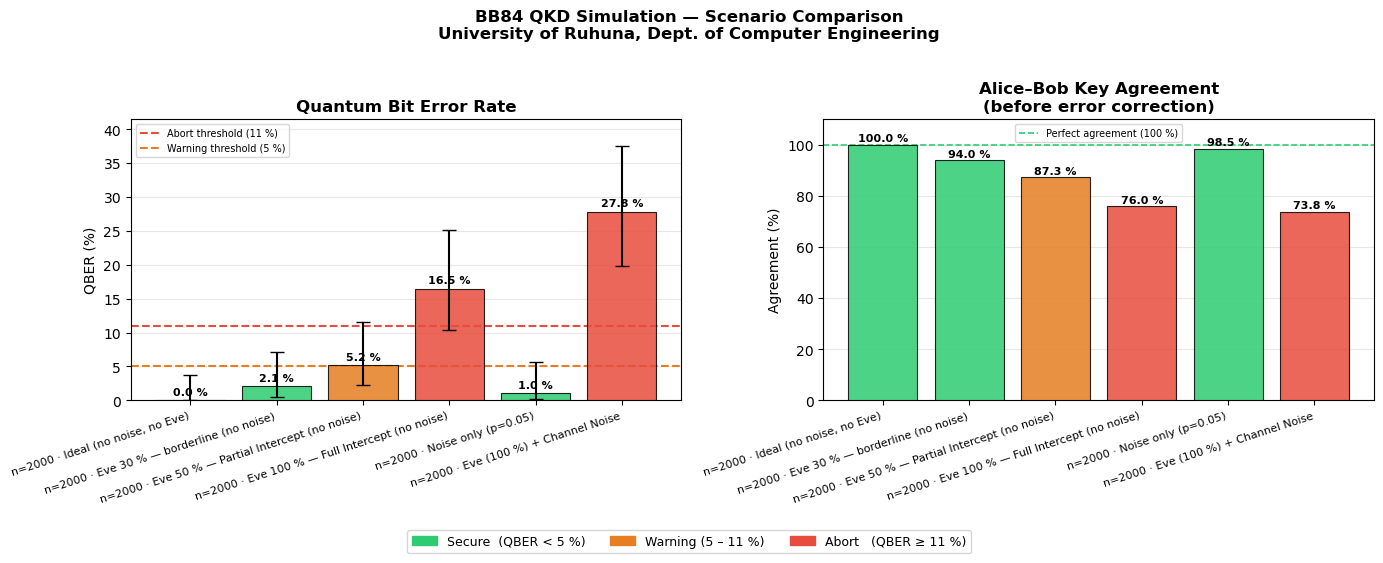

In [111]:
plot_comparison(
    scenarios = PHASE1_DETECTION_PROOF_HIGH,
    results   = results_high_qubit_2000,
    save_path = "qkd_comparison_high_qubit_2000.png",   # set None to skip saving
)

---
## Cell 6 — Research Experiment: QBER vs Eve Intercept Rate


  [Experiment] QBER vs Eve Intercept Rate sweep...
    p = 0.00  →  QBER = 0.0 %
    p = 0.10  →  QBER = 5.0 %
    p = 0.20  →  QBER = 0.0 %
    p = 0.30  →  QBER = 5.0 %
    p = 0.40  →  QBER = 10.0 %
    p = 0.50  →  QBER = 10.0 %
    p = 0.60  →  QBER = 15.0 %
    p = 0.70  →  QBER = 5.0 %
    p = 0.80  →  QBER = 20.0 %
    p = 0.90  →  QBER = 20.0 %
    p = 1.00  →  QBER = 15.0 %
  [✓] Saved → qkd_qber_vs_eve.png


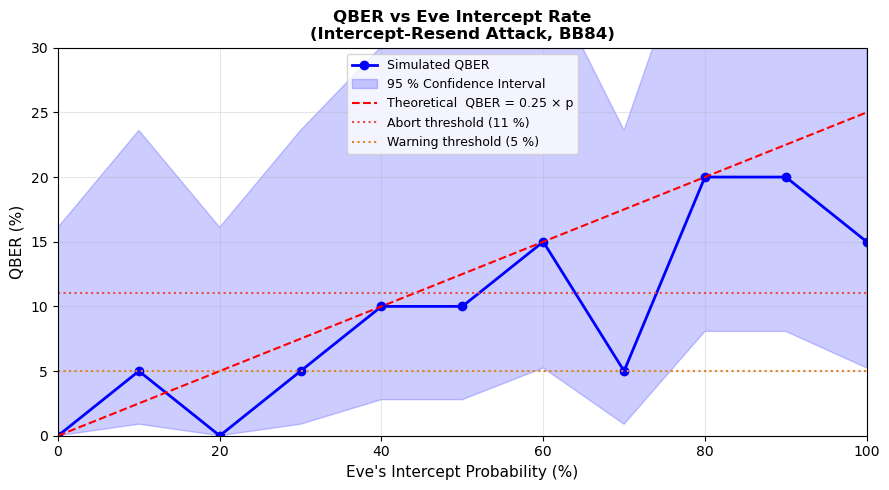

In [7]:
# Sweeps Eve's intercept probability 0 % → 100 % in `steps` steps.
# Plots simulated QBER vs theoretical prediction (QBER = 0.25 × p).
plot_qber_vs_intercept_rate(
    n_qubits  = 400,
    steps     = 10,
    save_path = "qkd_qber_vs_eve.png",
)


  [Experiment] QBER vs Eve Intercept Rate sweep...
    p = 0.00  →  QBER = 0.0 %
    p = 0.10  →  QBER = 3.1 %
    p = 0.20  →  QBER = 7.2 %
    p = 0.30  →  QBER = 12.4 %
    p = 0.40  →  QBER = 8.2 %
    p = 0.50  →  QBER = 10.3 %
    p = 0.60  →  QBER = 19.6 %
    p = 0.70  →  QBER = 18.6 %
    p = 0.80  →  QBER = 15.5 %
    p = 0.90  →  QBER = 13.4 %
    p = 1.00  →  QBER = 25.8 %
  [✓] Saved → qkd_qber_vs_eve.png


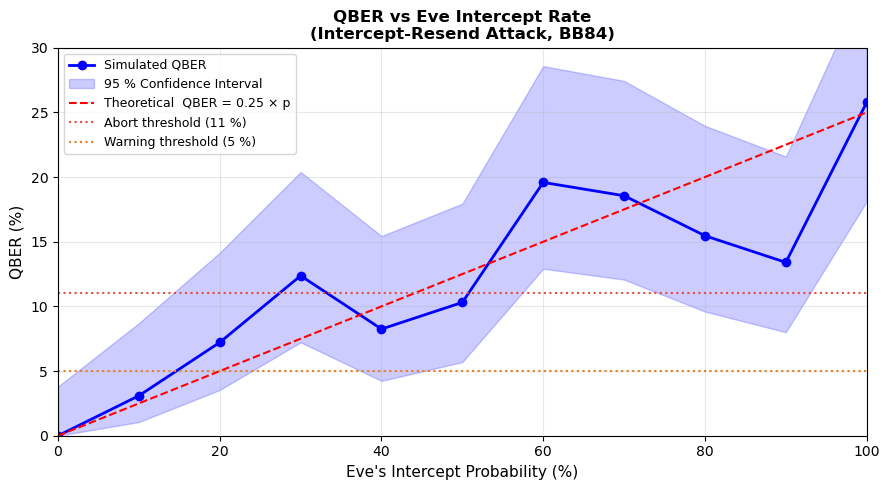

In [3]:
plot_qber_vs_intercept_rate(
    n_qubits  = 2000,
    steps     = 10,
    save_path = "qkd_qber_vs_eve.png",
)

---
## Cell 7 — Quick Access to Result Fields

In [ ]:
# Inspect any result programmatically
r = result_ideal

print(f"Transmitted      : {r.n_transmitted} qubits")
print(f"Sifted           : {r.n_sifted} bits ({r.sifted_key_rate:.1%})")
print(f"Final key length : {r.key_length} bits")
print(f"Key gen rate     : {r.key_generation_rate:.4f} bits/qubit")
print(f"QBER             : {r.qber_result.qber * 100:.2f} %")
print(f"Security status  : {r.qber_result.security_status}")
print(f"Keys match       : {r.keys_match}")
print(f"Runtime          : {r.runtime_seconds:.2f}s")

In [ ]:
my_cfg = SimulationConfig(
    n_qubits           = 800,       # ← change me
    eve_present        = True,      # ← toggle Eve
    eve_intercept_prob = 0.30,      # ← Eve intercepts 30 % of qubits
    noise_enabled      = False,     # ← toggle channel noise
    depolar_prob       = 0.02,      # ← noise level (active only if noise_enabled=True)
    sample_fraction    = 0.10,      # ← 10 % of sifted key used for QBER check
    seed               = None,      # ← None = random run
    label              = "test",
)

my_result = run_simulation(my_cfg, verbose=True)